# 13 — Organ Enrichment & Gene-Disease Validation

GSEA prerank of each qualifying pair's PC importance ranking against Oh et al. 2023 organ plasma protein sets.

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import gseapy as gp
from gtex_biomarkers.config import Config

Config.ensure_dirs()
CORAL, STEEL, GRAY = "#C44E52", "#4878A8", "#AAAAAA"
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

imp = pd.read_csv(Config.TABLES_DIR / "pc_gene_importance_full.csv")
imp["gene_upper"] = imp["gene_name"].str.upper()

# Organ plasma proteins (Oh et al. 2023, Supp. Table 5)
plasma = pd.read_excel(Config.RAW_DIR / "41586_2023_6802_MOESM5_ESM.xlsx", sheet_name="ST5")
PLASMA = {organ: sorted(set(g.split(".")[0].upper() for g in plasma[organ].dropna()))
          for organ in plasma.columns}

# Pair-to-organ mapping built dynamically from pc_gene_importance_full.csv, restricted to organs present in the plasma reference.
TISSUE_TO_ORGAN = {
    "Liver": "Liver",
    "Lung": "Lung",
    "Small Intestine - Terminal Ileum": "Intestine",
    "Colon - Sigmoid": "Intestine", "Colon - Transverse": "Intestine",
    "Stomach": "Intestine",
    "Artery - Tibial": "Artery", "Artery - Aorta": "Artery",
    "Artery - Coronary": "Artery",
    "Heart - Left Ventricle": "Heart", "Heart - Atrial Appendage": "Heart",
    "Muscle - Skeletal": "Muscle",
    "Pancreas": "Pancreas",
    "Kidney - Cortex": "Kidney", "Kidney - Medulla": "Kidney",
    "Brain - Cortex": "Brain", "Brain - Cerebellum": "Brain",
    "Adipose - Subcutaneous": "Adipose",
    "Adipose - Visceral (Omentum)": "Adipose",
}
PAIR_ORGAN = {}
for tissue, cat in imp.groupby(["tissue", "category"]).groups.keys():
    organ = TISSUE_TO_ORGAN.get(tissue)
    if organ and organ in PLASMA:
        PAIR_ORGAN[(tissue, cat)] = organ
PAIRS = list(PAIR_ORGAN.keys())
print(f"\nPair -> organ mapping ({len(PAIRS)} qualifying pairs):")
for p, o in PAIR_ORGAN.items():
    print(f"  {p[0]} | {p[1]} -> {o}")

print("Plasma protein gene set sizes:", {k: len(v) for k,v in PLASMA.items() if k in set(PAIR_ORGAN.values())})

In [2]:
def build_rnk(pair):
    """Importance-ranked DataFrame (uppercase gene symbols, no ENSG)."""
    df = imp[(imp["tissue"]==pair[0]) & (imp["category"]==pair[1])].sort_values("rank")
    df = df[~df["gene_name"].str.startswith("ENSG")].drop_duplicates("gene_upper")
    s = df.set_index("gene_upper")["importance"].sort_values(ascending=False)
    s.index.name = None
    # Return as 2-column DataFrame (gseapy 1.1+ expects this format)
    return s.reset_index().rename(columns={"index": "gene", "importance": "score"})

GSEA_COLS = ["Term","ES","NES","NOM p-val","FDR q-val","FWER p-val","Tag %","Gene %","Lead_genes"]

def run_gsea(rnk, gene_list, name, min_size=5):
    """GSEA prerank. Returns full result row as Series, or None."""
    try:
        res = gp.prerank(rnk=rnk, gene_sets={name: gene_list},
                         min_size=min_size, max_size=1000,
                         permutation_num=1000, seed=Config.SEED,
                         no_plot=True, verbose=False)
        r = res.res2d.copy()
        for c in ["ES","NES","NOM p-val","FDR q-val","FWER p-val"]:
            r[c] = pd.to_numeric(r[c], errors="coerce")
        return r.iloc[0]
    except Exception as e:
        print(f"GSEA failed for {name}: {e}")
        return None

def label(p): return f"{p[0]} | {p[1]}"

## 13.1 — Example: Liver | cirrhosis

GSEA prerank of the Liver | cirrhosis ranking against Oh et al. Liver plasma proteins, with rank-position and importance-curve deep-dives.

In [ ]:
pair = ("Liver", "cirrhosis")
organ = PAIR_ORGAN[pair]
rnk = build_rnk(pair)

r_plasma = run_gsea(rnk, PLASMA[organ], f"Plasma_{organ}")
gsea_table = pd.DataFrame([r_plasma])[GSEA_COLS]
gsea_table.insert(0, "source", ["Plasma"])
gsea_table.insert(1, "n_genes", [len(PLASMA[organ])])
gsea_table["Lead_genes"] = gsea_table["Lead_genes"].str[:80] + "..."
print(f"Liver | cirrhosis — GSEA prerank vs {len(PLASMA[organ])} Liver plasma proteins:")
display(gsea_table.drop(columns="Term"))

rk = imp[(imp["tissue"]==pair[0]) & (imp["category"]==pair[1])].sort_values("rank")
liver_set = set(PLASMA[organ])
hits = rk[rk["gene_upper"].isin(liver_set)][["rank","gene_name","importance"]]
print(f"\n{len(hits)} Liver plasma protein genes found in the 20K ranking. Top 20:")
display(hits.head(20))

genes_ranked = rnk["gene"].values
imp_ranked = rnk["score"].values
N = len(genes_ranked)
hit_ranks = np.array([i+1 for i, g in enumerate(genes_ranked) if g in liver_set])
hit_imps = np.array([imp_ranked[i] for i, g in enumerate(genes_ranked) if g in liver_set])

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(18, 5))

# (a) Rank positions of the top 50 Liver plasma protein genes
top50 = hits.head(50)
ax0.scatter(top50["rank"], range(len(top50)), c=STEEL, s=30, zorder=3)
for i, (_, r) in enumerate(top50.head(15).iterrows()):
    ax0.annotate(r["gene_name"], (r["rank"], i),
                 fontsize=6, xytext=(8, 0), textcoords="offset points")
ax0.axvline(1000, color=GRAY, ls=":", lw=0.8, label="Top 1000")
ax0.axvline(5000, color=GRAY, ls="--", lw=0.5, label="Top 5000")
ax0.set(xlabel="Gene rank (out of 20,000)",
        title="(a) Top-50 Liver plasma proteins — rank positions")
ax0.legend(fontsize=8)

# (b) Density histogram: hits vs uniform background
ax1.hist(np.arange(1, N+1), bins=20, density=True, color=GRAY, alpha=0.5,
         label="All genes")
ax1.hist(hit_ranks, bins=20, density=True, color=CORAL, alpha=0.7,
         label="Liver plasma proteins")
ax1.set_xlabel("Rank (1 = most important)")
ax1.set_ylabel("Density")
ax1.set_title(f"(b) Rank distribution  (p = {r_plasma['NOM p-val']:.2e})")
ax1.legend(loc="upper right", fontsize=9)

# (c) Importance curve with hits overlaid
ax2.plot(np.arange(1, N+1), imp_ranked, color=GRAY, lw=0.6, label="All genes")
ax2.scatter(hit_ranks, hit_imps, color=CORAL, s=18, zorder=3,
            label=f"Liver plasma proteins ({len(hit_ranks)} genes)")
ax2.set_xlabel("Gene rank")
ax2.set_ylabel("Importance score")
ax2.set_title("(c) Importance curve with plasma protein hits overlaid")
ax2.legend(loc="upper right", fontsize=9)

plt.tight_layout()
fig.savefig(Config.FIGURES_DIR / "plasma_liver_cirrhosis_deepdive.pdf", bbox_inches="tight")
plt.show()

## 13.2 — Scale to All Qualifying Pairs

Run GSEA prerank for every pair in `PAIR_ORGAN` against its organ's plasma protein set.

In [ ]:
rows = []
for p in PAIRS:
    organ = PAIR_ORGAN[p]
    rnk = build_rnk(p)
    lbl = label(p)

    if organ not in PLASMA:
        continue
    r = run_gsea(rnk, PLASMA[organ], f"Plasma_{organ}")
    if r is None:
        continue
    rows.append({"pair": lbl, "organ": organ,
                 "n": len(PLASMA[organ]), "ES": r["ES"], "NES": r["NES"],
                 "p": r["NOM p-val"], "FDR": r["FDR q-val"],
                 "Tag %": r["Tag %"], "Gene %": r["Gene %"],
                 "Lead_genes": r["Lead_genes"]})

results_plasma = pd.DataFrame(rows)
display(results_plasma.drop(columns="Lead_genes"))

print("\nLeading-edge genes (p < 0.05):")
for _, r in results_plasma[results_plasma["p"] < 0.05].iterrows():
    genes = r["Lead_genes"].split(";")
    print(f"\n  {r['pair']} ({len(genes)} genes):")
    print(f"    {', '.join(genes[:15])}{'...' if len(genes)>15 else ''}")

## 13.3 — NES Comparison Across Pairs

Bar chart of GSEA NES across pairs. Coral = p < 0.05.

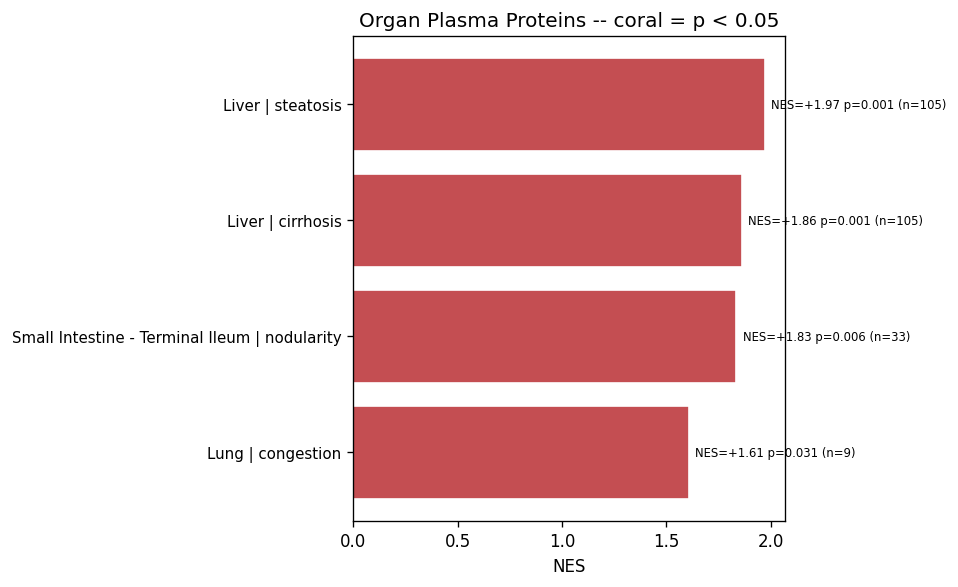

In [5]:
df = results_plasma.sort_values("NES", ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
y = range(len(df))
colors = [CORAL if p < 0.05 else GRAY for p in df["p"]]
ax.barh(y, df["NES"], color=colors, edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels(df["pair"], fontsize=9)
ax.axvline(0, color="black", lw=0.5)
ax.set(xlabel="NES", title="Organ Plasma Proteins -- coral = p < 0.05")

# Annotate NES, p, n on each bar
for i, (_, r) in enumerate(df.iterrows()):
    p_txt = f"p={r['p']:.3f}" if not np.isnan(r['p']) else ""
    ax.text(max(r["NES"]+0.03, 0.05), i,
            f"NES={r['NES']:+.2f} {p_txt} (n={int(r['n'])})",
            va="center", fontsize=7)

plt.tight_layout()
fig.savefig(Config.FIGURES_DIR / "plasma_nes_bar_all_pairs.pdf", bbox_inches="tight")
plt.show()

## 13.4 — Plasma Protein Leading-Edge Genes Across Pairs

Rank of each leading-edge gene in every pair's ranking — reveals shared vs pair-specific priorities.

In [ ]:
sig = results_plasma[results_plasma["p"] < 0.05]

le_genes = set()
for _, r in sig.iterrows():
    le_genes |= set(r["Lead_genes"].split(";"))

pair_labels = [label(p) for p in PAIRS]
rank_matrix = []
for gene in sorted(le_genes):
    row = {"gene": gene}
    for p in PAIRS:
        rk = imp[(imp["tissue"]==p[0]) & (imp["category"]==p[1])]
        match = rk[rk["gene_upper"] == gene]
        row[label(p)] = int(match["rank"].iloc[0]) if len(match) else np.nan
    rank_matrix.append(row)

rank_df = pd.DataFrame(rank_matrix).set_index("gene")
print(f"{len(rank_df)} leading-edge genes across {len(pair_labels)} pairs")

top_le = rank_df.mean(axis=1).nsmallest(30).index
plot_data = rank_df.loc[top_le][pair_labels]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(plot_data.values, cmap="RdYlGn_r", aspect="auto", vmin=1, vmax=20000)
ax.set_xticks(range(len(pair_labels)))
ax.set_xticklabels(pair_labels, rotation=45, ha="right", fontsize=10)
ax.set_yticks(range(len(top_le)))
ax.set_yticklabels(top_le, fontsize=9)

for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        v = plot_data.values[i, j]
        if np.isnan(v):
            ax.text(j, i, "—", ha="center", va="center", fontsize=8, color="gray")
            continue
        color = "white" if v < 3000 else "black"
        ax.text(j, i, f"{int(v):,}", ha="center", va="center", fontsize=8, color=color)

ax.set_title("Plasma Protein Leading-Edge Gene Ranks Across All Pairs\n(green = high rank, red = low rank)",
             fontsize=12)
plt.colorbar(im, ax=ax, shrink=0.5, label="Rank (1 = most important)")
plt.tight_layout()
fig.savefig(Config.FIGURES_DIR / "plasma_leading_edge_heatmap.pdf", bbox_inches="tight")
plt.show()

print("\nTop leading-edge genes by mean rank across all pairs:")
mean_ranks = rank_df.mean(axis=1).sort_values()
for gene in mean_ranks.head(15).index:
    ranks = rank_df.loc[gene]
    top_pair = ranks.idxmin()
    print(f"  {gene:12s}  mean={ranks.mean():,.0f}  best={int(ranks.min()):,} ({top_pair})")

## 13.5 — Per-Pair Plasma Enrichment Summary

Own-organ NES per pair (asterisks = p < 0.05).

In [ ]:
pair_order = [label(p) for p in PAIRS]
score = (pd.DataFrame({"pair": pair_order})
         .merge(results_plasma[["pair","NES","p"]]
                .rename(columns={"NES":"NES_Plasma","p":"p_Plasma"}),
                on="pair", how="left"))

data = score[["NES_Plasma"]].values.astype(float)
pvals = score[["p_Plasma"]].values.astype(float)
vmax = max(np.nanmax(np.abs(data)) if np.isfinite(np.nanmax(np.abs(data))) else 2.0, 1.0)

fig, ax = plt.subplots(figsize=(4.5, 0.5 * len(score) + 1.5))
im = ax.imshow(data, cmap="RdYlGn", aspect="auto", vmin=-vmax, vmax=vmax)
ax.set_xticks([0]); ax.set_xticklabels(["Plasma Proteins\nNES"], fontsize=9)
ax.set_yticks(range(len(score))); ax.set_yticklabels(score["pair"], fontsize=9)
for i in range(data.shape[0]):
    v, pv = data[i, 0], pvals[i, 0]
    if np.isnan(v):
        ax.text(0, i, "—", ha="center", va="center", fontsize=10, color="gray")
        continue
    star = "*" if (not np.isnan(pv) and pv < 0.05) else ""
    ax.text(0, i, f"{v:+.2f}{star}", ha="center", va="center", fontsize=9, color="black")
ax.set_title("Per-pair Plasma NES (* = p < 0.05)")
plt.colorbar(im, ax=ax, shrink=0.7, label="NES")
plt.tight_layout()
fig.savefig(Config.FIGURES_DIR / "plasma_nes_summary.pdf", bbox_inches="tight")
plt.show()
score

## 13.6 — Plasma Leading-Edge Flagship Genes

Per-pair leading-edge genes — the most credible organ-secreted biomarker candidates.

In [8]:
# Flagship genes: leading edge of the plasma GSEA per pair.
def _le_set(df, pair_label):
    row = df[df["pair"] == pair_label]
    if row.empty or pd.isna(row.iloc[0]["Lead_genes"]):
        return set()
    return set(str(row.iloc[0]["Lead_genes"]).split(";"))

rows = []
for p in PAIRS:
    lbl = label(p)
    plasma_le = _le_set(results_plasma, lbl)
    if not plasma_le:
        continue
    rk = imp[(imp["tissue"]==p[0]) & (imp["category"]==p[1])].sort_values("rank")
    for gene in sorted(plasma_le):
        match = rk[rk["gene_upper"] == gene]
        if match.empty:
            continue
        rows.append({"pair": lbl, "gene": gene, "rank": int(match["rank"].iloc[0])})

flagship = (pd.DataFrame(rows).sort_values(["pair","rank"])
            if rows else pd.DataFrame(columns=["pair","gene","rank"]))
print(f"Flagship genes (plasma leading edge): {len(flagship)}")
flagship

Flagship genes (plasma leading edge): 194


,pair,gene,rank
25,Liver | cirrhosis,C4BPA,1426
41,Liver | cirrhosis,EPO,1980
36,Liver | cirrhosis,CLEC4M,2422
22,Liver | cirrhosis,ASGR2,2558
72,Liver | cirrhosis,SAA2,2691
...,...,...,...
185,Small Intestine - Terminal Ileum | nodularity,APOA4,4424
191,Small Intestine - Terminal Ileum | nodularity,LGALS4,4446
193,Small Intestine - Terminal Ileum | nodularity,REG4,5132
190,Small Intestine - Terminal Ileum | nodularity,FABP6,5212


## 13.7 — Plasma Cross-Organ Specificity

Test each pair against every organ's plasma set — diagonal own-organ NES vs off-diagonal quantifies specificity.

In [ ]:
import itertools

# Exclude Conventional (4.5K genes) and Organismal (3.7K genes) — the paper's ubiquitous-protein controls,
# whose sizes would dominate any GSEA. Keep organ columns with >= 5 genes.
EXCLUDE_FROM_CROSS = {"Conventional", "Organismal"}
plasma_organs = sorted([o for o, g in PLASMA.items()
                        if len(g) >= 5 and o not in EXCLUDE_FROM_CROSS])
print(f"Plasma organ sets evaluated (>= 5 genes): {plasma_organs}")
print(f"Set sizes: {[(o, len(PLASMA[o])) for o in plasma_organs]}")

jac_mat = pd.DataFrame(index=plasma_organs, columns=plasma_organs, dtype=float)
for a, b in itertools.product(plasma_organs, repeat=2):
    A, B = set(PLASMA[a]), set(PLASMA[b])
    jac_mat.loc[a, b] = len(A & B) / len(A | B) if (A | B) else 0.0

print("\nPairwise Jaccard of plasma protein sets (off-diagonal):")
off = jac_mat.where(~np.eye(len(plasma_organs), dtype=bool))
print(f"  median Jaccard = {off.values[~np.isnan(off.values)].mean():.3f}")
print(f"  max Jaccard    = {np.nanmax(off.values):.3f}")
print(f"  top overlaps:")
pairs_jac = [(a, b, jac_mat.loc[a,b]) for a, b in itertools.combinations(plasma_organs, 2)]
for a, b, j in sorted(pairs_jac, key=lambda x: -x[2])[:5]:
    print(f"    {a} <-> {b}: {j:.3f}")

In [ ]:
cross_rows = []
for p in PAIRS:
    lbl = label(p)
    rnk = build_rnk(p)
    own_organ = PAIR_ORGAN[p]
    for organ_set in plasma_organs:
        r = run_gsea(rnk, PLASMA[organ_set], f"Plasma_{organ_set}", min_size=5)
        if r is None:
            continue
        cross_rows.append({
            "pair": lbl, "organ_set": organ_set,
            "n_genes": len(PLASMA[organ_set]),
            "NES": float(r["NES"]) if pd.notna(r["NES"]) else np.nan,
            "p":   float(r["NOM p-val"]) if pd.notna(r["NOM p-val"]) else np.nan,
            "FDR": float(r["FDR q-val"]) if pd.notna(r["FDR q-val"]) else np.nan,
            "is_own": organ_set == own_organ,
        })
cross_plasma = pd.DataFrame(cross_rows)
print(f"Computed {len(cross_plasma)} pair x organ-set GSEA tests")

nes_mat = cross_plasma.pivot(index="pair", columns="organ_set", values="NES")
nes_mat = nes_mat.reindex([label(p) for p in PAIRS])
sig_mat = cross_plasma.pivot(index="pair", columns="organ_set", values="p") < 0.05
sig_mat = sig_mat.reindex([label(p) for p in PAIRS]).reindex(columns=nes_mat.columns)

vmax = np.nanmax(np.abs(nes_mat.values))
fig, ax = plt.subplots(figsize=(max(8, 0.9 * nes_mat.shape[1]), max(3, 0.9 * nes_mat.shape[0])))
im = ax.imshow(nes_mat.values, cmap="RdBu_r", aspect="auto", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(nes_mat.shape[1]))
ax.set_xticklabels(nes_mat.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(nes_mat.shape[0]))
ax.set_yticklabels(nes_mat.index, fontsize=9)
for i, pair_lbl in enumerate(nes_mat.index):
    own_organ = PAIR_ORGAN[PAIRS[i]]
    for j, organ_col in enumerate(nes_mat.columns):
        v = nes_mat.iloc[i, j]
        if np.isnan(v):
            continue
        star = "*" if sig_mat.iloc[i, j] else ""
        color = "white" if abs(v) > vmax * 0.55 else "black"
        ax.text(j, i, f"{v:+.2f}{star}", ha="center", va="center", fontsize=7.5, color=color)
        if organ_col == own_organ:
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor="black", lw=2))
ax.set_title("Cross-Organ Plasma Protein Enrichment (NES; * = p<0.05; box = own-organ)", fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.7, label="NES (signed)")
plt.tight_layout()
fig.savefig(Config.FIGURES_DIR / "cross_organ_plasma_nes.pdf", bbox_inches="tight")
plt.show()

In [ ]:
spec_rows = []
for p in PAIRS:
    lbl = label(p)
    sub = cross_plasma[cross_plasma["pair"] == lbl]
    own = sub[sub["is_own"]]
    other = sub[~sub["is_own"]]
    if own.empty:
        continue
    nes_own = float(own["NES"].iloc[0])
    nes_other = other["NES"].astype(float).values
    nes_other_max = float(np.nanmax(nes_other)) if len(nes_other) and np.any(np.isfinite(nes_other)) else np.nan
    nes_other_mean = float(np.nanmean(nes_other)) if len(nes_other) and np.any(np.isfinite(nes_other)) else np.nan
    spec_rows.append({
        "pair": lbl,
        "own_organ": PAIR_ORGAN[p],
        "NES_own": round(nes_own, 3),
        "NES_other_max": round(nes_other_max, 3) if pd.notna(nes_other_max) else np.nan,
        "NES_other_mean": round(nes_other_mean, 3) if pd.notna(nes_other_mean) else np.nan,
        "specificity_ratio": round(nes_own / nes_other_max, 2) if pd.notna(nes_other_max) and nes_other_max > 0 else np.nan,
        "delta_NES_vs_max": round(nes_own - nes_other_max, 3) if pd.notna(nes_other_max) else np.nan,
    })
spec_plasma = pd.DataFrame(spec_rows)
print("Plasma cross-organ specificity per pair:")
display(spec_plasma)

print()
print(f"Mean own-organ NES:           {spec_plasma['NES_own'].mean():.3f}")
print(f"Mean best-off-organ NES:      {spec_plasma['NES_other_max'].mean():.3f}")
print(f"Mean specificity ratio:       {spec_plasma['specificity_ratio'].mean():.2f}x")
print(f"Mean delta (NES_own - other): +{spec_plasma['delta_NES_vs_max'].mean():.3f}")

cross_plasma.to_csv(Config.TABLES_DIR / "cross_organ_plasma_gsea_full.csv", index=False)
spec_plasma.to_csv(Config.TABLES_DIR / "cross_organ_specificity_plasma.csv", index=False)
print("\nSaved: cross_organ_plasma_gsea_full.csv, cross_organ_specificity_plasma.csv")

## 13.8 — Export

Save GSEA results, leading-edge rank matrix, scorecard, and flagship gene list.

In [12]:
results_plasma.to_csv(Config.TABLES_DIR / "organ_enrichment_plasma_gsea.csv", index=False)
rank_df.to_csv(Config.TABLES_DIR / "organ_leading_edge_ranks.csv")
score.to_csv(Config.TABLES_DIR / "plasma_nes_summary.csv", index=False)
flagship.to_csv(Config.TABLES_DIR / "validation_flagship_genes.csv", index=False)

print("Saved:")
print(f"  organ_enrichment_plasma_gsea.csv    ({len(results_plasma)} rows)")
print(f"  organ_leading_edge_ranks.csv        ({len(rank_df)} genes x {rank_df.shape[1]} pairs)")
print(f"  plasma_nes_summary.csv              ({len(score)} rows)")
print(f"  validation_flagship_genes.csv       ({len(flagship)} rows)")

print("\nSignificant plasma enrichments (p < 0.05):")
sig = results_plasma.dropna(subset=["p"])
sig = sig[sig["p"] < 0.05]
print(f"  {len(sig)}/{len(results_plasma)} tests")
for _, r in sig.sort_values("NES", ascending=False).iterrows():
    pair_str = r["pair"]
    nes = r["NES"]
    pv = r["p"]
    print(f"    {pair_str:50s} NES={nes:+.2f} p={pv:.4f}")

Saved:
  organ_enrichment_plasma_gsea.csv    (4 rows)
  organ_leading_edge_ranks.csv        (110 genes x 4 pairs)
  plasma_nes_summary.csv              (4 rows)
  validation_flagship_genes.csv       (194 rows)

Significant plasma enrichments (p < 0.05):
  4/4 tests
    Liver | steatosis                                  NES=+1.97 p=0.0010
    Liver | cirrhosis                                  NES=+1.86 p=0.0010
    Small Intestine - Terminal Ileum | nodularity      NES=+1.83 p=0.0059
    Lung | congestion                                  NES=+1.61 p=0.0311
